## Robustness Evaluation of AI-Generated Financial Misinformation Detection

This notebook evaluates the robustness of misinformation detection models when exposed to synthetic AI-generated financial news.

The objectives are:

1. Improve model performance through hyperparameter tuning.
2. Assess model generalization across different AI-generated misinformation styles.
3. Analyze prediction errors and model vulnerabilities.



## Imports

In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Paths
project_path = "..."

## Load Data

In [ ]:
# Load final feature dataset
features_df = pd.read_csv(
    f"{project_path}/data/processed/features_dataset.csv"
)

features_df.shape

(400, 16)

In [ ]:
features_df["label"].value_counts()

,count
label,
1,300
0,100


In [ ]:
# Load synthetic dataset
synthetic_df = pd.read_csv(
    f"{project_path}/data/processed/synthetic_financial_news.csv"
)

synthetic_df.shape

(400, 7)

In [ ]:
synthetic_df["prompt_type"].value_counts()

,count
prompt_type,
original,100
bullish,100
bearish,100
neutral,100


In [ ]:
# Prepare Real Training Data
X = features_df["article"]
y = features_df["label"]

In [ ]:
# Split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## TF-IDF for Robustness

AI-generated misinformation may vary in style and severity.

Therefore, the detection models are evaluated against multiple synthetic
generation strategies:

- Bullish misinformation: exaggerated positive claims
- Bearish misinformation: exaggerated negative claims
- Neutral rewrite: AI-generated text with preserved factual meaning

The goal is to evaluate whether models remain effective when misinformation
becomes less obvious.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(
    X_train_text
)

X_test_tfidf = tfidf.transform(
    X_test_text
)

## Hyperparameter Tuning

Randomized search with cross-validation was applied to improve baseline
models.

The optimisation criterion was F1-score because the task requires balancing
correct detection of AI-generated content while avoiding false accusations
against real articles.

In [ ]:
# Random Forest tuning
rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5,10]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    rf_params,
    n_iter=5,
    cv=3,
    scoring="f1",
    random_state=42
)

rf_search.fit(
    X_train_tfidf,
    y_train
)

best_rf = rf_search.best_estimator_

best_rf

RandomForestClassifier(max_depth=20, min_samples_split=5, random_state=42)

In [ ]:
# SVM tuning
svm_params = {
    "C":[0.1,1,10],
    "kernel":["linear","rbf"]
}

svm_search = RandomizedSearchCV(
    SVC(
        probability=True,
        random_state=42
    ),
    svm_params,
    n_iter=4,
    cv=3,
    scoring="f1"
)

svm_search.fit(
    X_train_tfidf,
    y_train
)

best_svm = svm_search.best_estimator_

best_svm

SVC(C=10, kernel='linear', probability=True, random_state=42)

In [ ]:
# Neural Network tuning
nn_params = {
    "hidden_layer_sizes":[(100,),(150,),(100,50)],
    "learning_rate_init":[0.001,0.0005]
}

nn_search = RandomizedSearchCV(
    MLPClassifier(
        max_iter=500,
        random_state=42
    ),
    nn_params,
    n_iter=4,
    cv=3,
    scoring="f1",
    random_state=42
)

nn_search.fit(
    X_train_tfidf,
    y_train
)

best_nn = nn_search.best_estimator_

best_nn

MLPClassifier(hidden_layer_sizes=(150,), max_iter=500, random_state=42)

## Evaluate Tuned Models



In [ ]:
def evaluate_model(
    model,
    X,
    y
):

    pred = model.predict(X)

    prob = model.predict_proba(X)[:,1]

    return {

        "Accuracy":
        accuracy_score(y,pred),

        "Precision":
        precision_score(y,pred),

        "Recall":
        recall_score(y,pred),

        "F1":
        f1_score(y,pred),

        "ROC_AUC":
        roc_auc_score(y,prob)
    }

In [ ]:
tuned_results = []

In [ ]:
rf_metrics = evaluate_model(
    best_rf,
    X_test_tfidf,
    y_test
)

rf_metrics["Model"] = "Tuned Random Forest"

tuned_results.append(
    rf_metrics
)

In [ ]:
svm_metrics = evaluate_model(
    best_svm,
    X_test_tfidf,
    y_test
)

svm_metrics["Model"] = "Tuned SVM"

tuned_results.append(
    svm_metrics
)

In [ ]:
nn_metrics = evaluate_model(
    best_nn,
    X_test_tfidf,
    y_test
)

nn_metrics["Model"] = "Tuned Neural Network"

tuned_results.append(
    nn_metrics
)

In [ ]:
tuned_results_df = pd.DataFrame(
    tuned_results
)

tuned_results_df

,Accuracy,Precision,Recall,F1,ROC_AUC,Model
0,0.8750,0.962963,0.866667,0.912281,0.938333,Tuned Random Forest
1,0.8375,0.927273,0.850000,0.886957,0.912500,Tuned SVM
2,0.7625,0.847458,0.833333,0.840336,0.836667,Tuned Neural Network


**Hyperparameter Tuning Results**

Hyperparameter optimization improved the performance of the classical machine learning models.

Among the tuned models, Random Forest achieved the strongest performance with an F1-score of 0.912 and ROC-AUC of 0.938. SVM achieved an F1-score of 0.887, while the Neural Network achieved an F1-score of 0.840.

These results indicate that careful parameter selection can substantially improve misinformation detection performance, particularly for ensemble-based approaches such as Random Forest.

In [ ]:
tuned_results_df.to_csv(
    f"{project_path}/results/tuned_model_results.csv",
    index=False
)

## Robustness Sets

In [ ]:
bullish_df = synthetic_df[
    synthetic_df["prompt_type"] == "bullish"
].copy()

bearish_df = synthetic_df[
    synthetic_df["prompt_type"] == "bearish"
].copy()

neutral_df = synthetic_df[
    synthetic_df["prompt_type"] == "neutral"
].copy()

## TF-IDF Transform


In [ ]:
bullish_tfidf = tfidf.transform(
    bullish_df["generated_article"]
)

bearish_tfidf = tfidf.transform(
    bearish_df["generated_article"]
)

neutral_tfidf = tfidf.transform(
    neutral_df["generated_article"]
)

## Robustness Evaluation

In [ ]:
robustness_results = []

In [ ]:
datasets = {

    "Bullish":
    (bullish_tfidf,bullish_df["label"]),

    "Bearish":
    (bearish_tfidf,bearish_df["label"]),

    "Neutral":
    (neutral_tfidf,neutral_df["label"])
}

In [ ]:
models = {

    "RF":
    best_rf,

    "SVM":
    best_svm,

    "NN":
    best_nn
}

In [ ]:
for model_name, model in models.items():

    for dataset_name, (X_set,y_set) in datasets.items():

        metrics = evaluate_model(
            model,
            X_set,
            y_set
        )

        metrics["Model"] = model_name

        metrics["Dataset"] = dataset_name

        robustness_results.append(
            metrics
        )

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist

In [ ]:
robustness_df = pd.DataFrame(
    robustness_results
)

robustness_df

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Dataset
0,1.00,1.0,1.00,1.000000,NaN,RF,Bullish
1,1.00,1.0,1.00,1.000000,NaN,RF,Bearish
2,0.92,1.0,0.92,0.958333,NaN,RF,Neutral
3,1.00,1.0,1.00,1.000000,NaN,SVM,Bullish
4,1.00,1.0,1.00,1.000000,NaN,SVM,Bearish
5,0.91,1.0,0.91,0.952880,NaN,SVM,Neutral
6,1.00,1.0,1.00,1.000000,NaN,NN,Bullish
7,1.00,1.0,1.00,1.000000,NaN,NN,Bearish
8,0.90,1.0,0.90,0.947368,NaN,NN,Neutral


**Robustness Evaluation**

The robustness experiment evaluated model performance across three synthetic misinformation styles:

- Bullish misinformation
- Bearish misinformation
- Neutral AI-generated rewrites

The evaluated models achieved very high performance on bullish and bearish
synthetic misinformation samples.

However, performance decreased on neutral AI-generated rewrites. For example, Random Forest achieved an F1-score of 0.958 on neutral articles, compared with perfect performance on bullish and bearish variants.

This suggests that neutral rewrites more closely resemble authentic financial news and therefore represent a greater challenge for detection systems.

In [ ]:
robustness_df.to_csv(
    f"{project_path}/results/robustness_results.csv",
    index=False
)

## Robustness Performance Difference


In [ ]:
normal_f1 = {
    "RF": rf_metrics["F1"],
    "SVM": svm_metrics["F1"],
    "NN": nn_metrics["F1"]
}

In [ ]:
drop_rows = []

for model in ["RF","SVM","NN"]:

    avg_robust_f1 = robustness_df[
        robustness_df["Model"] == model
    ]["F1"].mean()

    drop_rows.append({

        "Model":model,

        "Normal_F1":
        normal_f1[model],

        "Robust_F1":
        avg_robust_f1,

        "F1_Drop":
        normal_f1[model]
        -
        avg_robust_f1
    })

In [ ]:
drop_df = pd.DataFrame(
    drop_rows
)

drop_df

,Model,Normal_F1,Robust_F1,F1_Drop
0,RF,0.872727,0.986111,-0.113384
1,SVM,0.888889,0.984293,-0.095404
2,NN,0.876923,0.982456,-0.105533


**Performance Comparison**

The models did not experience performance degradation on the synthetic
evaluation sets.

Instead, performance increased slightly, suggesting that the generated
misinformation contains detectable stylistic patterns.

This indicates that the current synthetic generation process may introduce
linguistic signals that make detection easier than naturally occurring
misinformation.

## Visualization

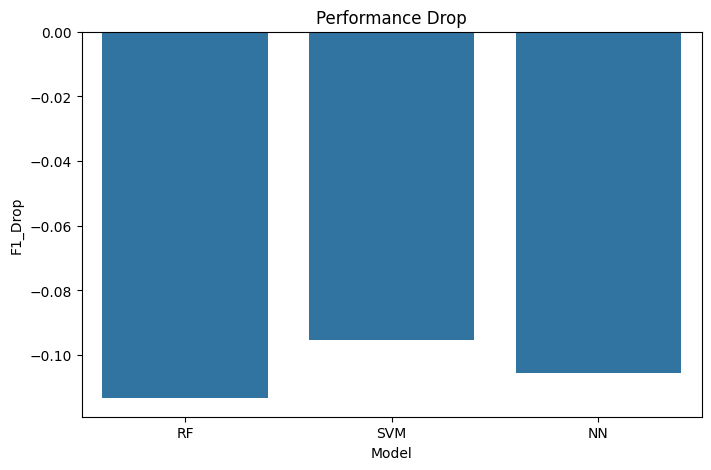

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=drop_df,
    x="Model",
    y="F1_Drop"
)

plt.title(
    "Performance Drop"
)

plt.savefig(
    f"{project_path}/figures/performance_drop.png",
    bbox_inches="tight"
)

plt.show()

The chart shows the F1 score drop for RF (‑0.113), SVM (‑0.095), and NN (‑0.106), with SVM having the smallest decline and RF/NN showing slightly larger drops.

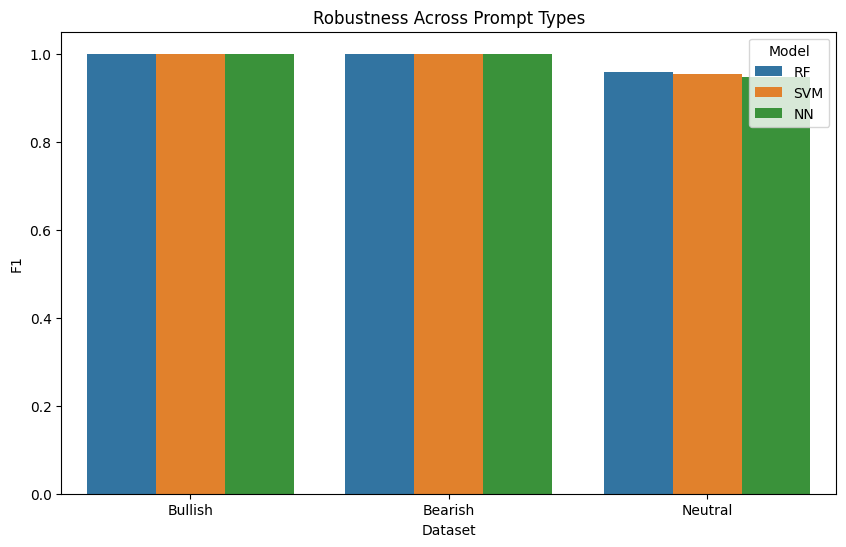

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=robustness_df,
    x="Dataset",
    y="F1",
    hue="Model"
)

plt.title(
    "Robustness Across Prompt Types"
)

plt.savefig(
    f"{project_path}/figures/robustness_comparison.png",
    bbox_inches="tight"
)

plt.show()

**Prompt-Type Analysis**

Detection performance varied across prompt types.

- Bullish and bearish misinformation achieved near-perfect classification performance across all evaluated models.

- In contrast, neutral AI-generated rewrites consistently produced lower performance and accounted for most observed classification errors. For example, the Random Forest model achieved an F1-score of 0.958 on neutral rewrites, compared with perfect performance on bullish and bearish variants.

These findings suggest that detection systems are highly effective against overtly misleading narratives but face greater difficulty when AI-generated content preserves the original informational content while only modifying wording and structure.

## Error Analysis

In [ ]:
best_model = best_rf

In [ ]:
neutral_pred = best_model.predict(
    neutral_tfidf
)

In [ ]:
neutral_df["prediction"] = neutral_pred

In [ ]:
false_negatives = neutral_df[
    neutral_df["prediction"] == 0
]

false_negatives.head(10)

,generated_article,original_article,prompt_type,source_type,label,company,length,prediction
114,"On Tuesday, stock futures experienced a sharp ...",Stock futures were tumbling on Tuesday as inve...,neutral,AI_generated,1,GOOGL,67,0
162,Chevron Corporation (NYSE: CVX) has been ident...,Chevron Corporation (NYSE:CVX) is one of the 1...,neutral,AI_generated,1,CVX,78,0
195,Shares of Block Inc (NYSE: SQ) surged 17% duri...,Block Inc (NYSE:SQ) shares rose 17% in early t...,neutral,AI_generated,1,SQ,49,0
198,In a recent episode of Motley Fool’s Hidden Ge...,A recent Motley Fool Hidden Gems Investing seg...,neutral,AI_generated,1,MCD,77,0
306,Leadership initially anchored its turnaround n...,Management once built its transformation story...,neutral,AI_generated,1,XOM,51,0
321,Amazon.com is set to use its upcoming Prime Da...,Amazon.com’s upcoming Prime Day will be a lit...,neutral,AI_generated,1,WMT,76,0
336,Holding a short interest equal to 1.21% of its...,With a short percentage of shares outstanding ...,neutral,AI_generated,1,HD,72,0
369,CGI has joined forces with Entersekt to improv...,CGI and Entersekt have partnered to enhance 3-...,neutral,AI_generated,1,PYPL,86,0


**Error Analysis**

Most misclassified examples originated from the neutral rewrite category.

Unlike bullish and bearish misinformation, neutral rewrites preserve the original informational content while modifying sentence structure and wording. As a result, they exhibit linguistic characteristics that are closer to authentic financial news.

Examples of false negatives show that models occasionally classified AI-generated rewrites as genuine articles when little semantic distortion was introduced.

This finding suggests that subtle AI-assisted rewriting poses a greater detection challenge than overtly misleading misinformation.

## Final Interpretation
The results suggest that current detection models remain highly effective when confronted with overtly misleading AI-generated financial misinformation.

Among the evaluated classical models, the tuned Random Forest demonstrated the strongest overall robustness. Although robustness testing focused on classical models due to computational constraints, FinBERT achieved the strongest detection results in the main evaluation.